In [ ]:
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from collections import defaultdict

DATA_PATH = "D:/soccernet-data"

competitions = os.listdir(DATA_PATH)
print("Competitions found:")
for c in competitions:
    print(f"  - {c}")
print(f"\nTotal competitions: {len(competitions)}")

In [ ]:
all_games = []

for competition in competitions:
    competition_path = os.path.join(DATA_PATH, competition)
    for season in os.listdir(competition_path):
        season_path = os.path.join(competition_path, season)
        for game in os.listdir(season_path):
            game_path = os.path.join(season_path, game)
            all_games.append(game_path)

print(f"Total games found: {len(all_games)}")
print(f"\nFirst 5 game paths:")
for g in all_games[:5]:
    print(f"  {g}")

In [ ]:
action_counts = defaultdict(int)
total_annotations = 0
games_with_labels = 0
games_without_labels = 0

for game_path in all_games:
    label_path = os.path.join(game_path, "Labels-v2.json")
    
    if not os.path.exists(label_path):
        games_without_labels += 1
        continue
    
    games_with_labels += 1
    with open(label_path, "r") as f:
        data = json.load(f)
    
    for annotation in data["annotations"]:
        action_counts[annotation["label"]] += 1
        total_annotations += 1

print(f"Games with labels: {games_with_labels}")
print(f"Games without labels: {games_without_labels}")
print(f"Total annotations: {total_annotations}")
print(f"\nAction counts (sorted by frequency):")
for action, count in sorted(action_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {action}: {count}")

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

actions = list(action_counts.keys())
counts = list(action_counts.values())
sorted_pairs = sorted(zip(counts, actions), reverse=True)
counts_sorted, actions_sorted = zip(*sorted_pairs)

ax1.barh(actions_sorted, counts_sorted, color="steelblue")
ax1.set_xlabel("Count")
ax1.set_title("All action classes — full distribution")
ax1.invert_yaxis()

selected_classes = ["Goal", "Corner", "Yellow card", "Substitution", 
                    "Shots on target", "Shots off target"]
selected_counts = [action_counts[c] for c in selected_classes]

ax2.barh(selected_classes, selected_counts, color="darkorange")
ax2.set_xlabel("Count")
ax2.set_title("Selected 6 classes for the project")
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig("../results/figures/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to results/figures/")

In [ ]:
sample_game = all_games[0]
half1_path = os.path.join(sample_game, "1_ResNET_TF2_PCA512.npy")
half2_path = os.path.join(sample_game, "2_ResNET_TF2_PCA512.npy")

half1 = np.load(half1_path)
half2 = np.load(half2_path)

print(f"Game: {os.path.basename(sample_game)}")
print(f"\nHalf 1 shape: {half1.shape}")
print(f"Half 2 shape: {half2.shape}")
print(f"\nWhat this means:")
print(f"  Frames in half 1: {half1.shape[0]} ({half1.shape[0]/2/60:.1f} minutes at 2fps)")
print(f"  Frames in half 2: {half2.shape[0]} ({half2.shape[0]/2/60:.1f} minutes at 2fps)")
print(f"  Feature dimensions per frame: {half1.shape[1]}")
print(f"\nFeature statistics for half 1:")
print(f"  Min value: {half1.min():.4f}")
print(f"  Max value: {half1.max():.4f}")
print(f"  Mean value: {half1.mean():.4f}")
print(f"  Std value: {half1.std():.4f}")

In [ ]:
label_path = os.path.join(sample_game, "Labels-v2.json")
with open(label_path, "r") as f:
    data = json.load(f)

print(f"Game: {os.path.basename(sample_game)}")
print(f"Total annotations in this game: {len(data['annotations'])}")
print(f"\nAll annotations:")
for ann in data["annotations"]:
    
    game_time = ann["gameTime"]
    half = int(game_time.split(" - ")[0])
    time_str = game_time.split(" - ")[1]
    minutes, seconds = map(int, time_str.split(":"))
    total_seconds = minutes * 60 + seconds
    frame_index = int(total_seconds * 2)
    
    print(f"  [{ann['label']}] Half {half} | {time_str} | "
          f"position={ann['position']}ms | frame_index={frame_index}")

In [ ]:
SELECTED_CLASSES = ["Goal", "Corner", "Yellow card", 
                    "Substitution", "Shots on target", "Shots off target"]

annotations_per_game = []
selected_counts_per_class = defaultdict(int)
games_with_zero = 0

for game_path in all_games:
    label_path = os.path.join(game_path, "Labels-v2.json")
    with open(label_path, "r") as f:
        data = json.load(f)
    
    game_annotations = [a for a in data["annotations"] 
                        if a["label"] in SELECTED_CLASSES]
    annotations_per_game.append(len(game_annotations))
    
    for ann in game_annotations:
        selected_counts_per_class[ann["label"]] += 1
    
    if len(game_annotations) == 0:
        games_with_zero += 1

print("Selected class totals across all 500 games:")
for cls in SELECTED_CLASSES:
    print(f"  {cls}: {selected_counts_per_class[cls]}")

print(f"\nTotal selected annotations: {sum(selected_counts_per_class.values())}")
print(f"Games with zero selected annotations: {games_with_zero}")
print(f"\nAnnotations per game statistics:")
print(f"  Min: {min(annotations_per_game)}")
print(f"  Max: {max(annotations_per_game)}")
print(f"  Mean: {np.mean(annotations_per_game):.1f}")
print(f"  Median: {np.median(annotations_per_game):.1f}")

In [ ]:
from SoccerNet.utils import getListGames

train_games = getListGames("train")
valid_games = getListGames("valid")
test_games = getListGames("test")

print(f"Train games: {len(train_games)}")
print(f"Valid games: {len(valid_games)}")
print(f"Test games: {len(test_games)}")
print(f"\nSample train game entry: {train_games[0]}")

In [ ]:
split_mapping = {}
for game in train_games:
    split_mapping[game] = "train"
for game in valid_games:
    split_mapping[game] = "valid"
for game in test_games:
    split_mapping[game] = "test"

split_stats = {
    "train": defaultdict(int),
    "valid": defaultdict(int),
    "test": defaultdict(int)
}
split_game_counts = {"train": 0, "valid": 0, "test": 0}

for game_path in all_games:
    label_path = os.path.join(game_path, "Labels-v2.json")
    with open(label_path, "r") as f:
        data = json.load(f)
    
    url_local = data.get("UrlLocal", "").replace("/", "\\").rstrip("\\")
    split = split_mapping.get(url_local, None)
    
    if split is None:
        continue
    
    split_game_counts[split] += 1
    for ann in data["annotations"]:
        if ann["label"] in SELECTED_CLASSES:
            split_stats[split][ann["label"]] += 1

for split in ["train", "valid", "test"]:
    total = sum(split_stats[split].values())
    print(f"\n{split.upper()} — {split_game_counts[split]} games, {total} annotations")
    for cls in SELECTED_CLASSES:
        print(f"  {cls}: {split_stats[split][cls]}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {"train": "steelblue", "valid": "darkorange", "test": "green"}

for idx, split in enumerate(["train", "valid", "test"]):
    counts = [split_stats[split][cls] for cls in SELECTED_CLASSES]
    axes[idx].barh(SELECTED_CLASSES, counts, color=colors[split])
    axes[idx].set_title(f"{split.upper()} — {split_game_counts[split]} games")
    axes[idx].set_xlabel("Count")
    axes[idx].invert_yaxis()
    for i, count in enumerate(counts):
        axes[idx].text(count + 10, i, str(count), va="center", fontsize=9)

plt.suptitle("Action class distribution per split", fontsize=14)
plt.tight_layout()
plt.savefig("../results/figures/split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to results/figures/")

In [ ]:
import sys
sys.path.append("../src")

from dataset import SoccerNetDataset
from torch.utils.data import DataLoader

DATA_PATH = "D:/soccernet-data"

train_dataset = SoccerNetDataset(
    data_path=DATA_PATH,
    split="train",
    window_size=60,
    overlap=0.5
)

In [ ]:
from collections import Counter

from dataset import IDX_TO_CLASS, BACKGROUND_IDX

labels = [label for _, label in train_dataset.samples]
label_counts = Counter(labels)

print("Sample counts per class:")
for idx, cls in IDX_TO_CLASS.items():
    print(f"  {cls}: {label_counts[idx]}")
print(f"  Background: {label_counts[BACKGROUND_IDX]}")

print(f"\nTotal action samples: {sum(label_counts[i] for i in range(len(SELECTED_CLASSES)))}")
print(f"Total background samples: {label_counts[BACKGROUND_IDX]}")

window, label = train_dataset[0]
print(f"\nSample window shape: {window.shape}")
print(f"Sample label: {label.item()} ({IDX_TO_CLASS.get(label.item(), 'Background')})")

In [ ]:
valid_dataset = SoccerNetDataset(
    data_path=DATA_PATH,
    split="valid",
    window_size=60,
    overlap=0.5
)

test_dataset = SoccerNetDataset(
    data_path=DATA_PATH,
    split="test",
    window_size=60,
    overlap=0.5
)

print(f"\nDataset summary:")
print(f"  Train samples: {len(train_dataset)}")
print(f"  Valid samples: {len(valid_dataset)}")
print(f"  Test samples:  {len(test_dataset)}")

In [ ]:
import sys
sys.path.append("../src")

from dataset import get_dataloader, IDX_TO_CLASS, SELECTED_CLASSES
from collections import Counter
import torch

train_loader = get_dataloader(train_dataset, batch_size=32, use_weighted_sampler=True)
valid_loader = get_dataloader(valid_dataset, batch_size=32, shuffle=False)
test_loader = get_dataloader(test_dataset, batch_size=32, shuffle=False)

batch_windows, batch_labels = next(iter(train_loader))
print(f"Batch windows shape: {batch_windows.shape}")
print(f"Batch labels shape: {batch_labels.shape}")
print(f"Labels in this batch: {batch_labels.tolist()}")
print(f"\nClass distribution in this batch:")
batch_counts = Counter(batch_labels.tolist())
for idx in range(len(SELECTED_CLASSES) + 1):
    cls_name = IDX_TO_CLASS.get(idx, "Background")
    print(f"  {cls_name}: {batch_counts.get(idx, 0)}")

In [ ]:
import sys
sys.path.append("../src")

from model import SoccerNetTransformer
import torch

model = SoccerNetTransformer(
    input_dim=512,
    d_model=256,
    num_heads=4,
    num_layers=3,
    dim_feedforward=512,
    dropout=0.1,
    num_classes=7
)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

batch_windows, batch_labels = next(iter(train_loader))
output = model(batch_windows)

print(f"\nInput shape: {batch_windows.shape}")
print(f"Output shape: {output.shape}")
print(f"Output (first sample): {output[0].detach().numpy().round(4)}")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = model.to(device)
batch_windows, batch_labels = next(iter(train_loader))
batch_windows = batch_windows.to(device)
batch_labels = batch_labels.to(device)

output = model(batch_windows)
print(f"Input device: {batch_windows.device}")
print(f"Output device: {output.device}")
print(f"Output shape: {output.shape}")
print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1024**2:.1f} MB")

In [ ]:
import sys
sys.path.append("../src")

from model import SoccerNetTransformer
from dataset import SoccerNetDataset, get_dataloader
from pretrain import pretrain

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SoccerNetTransformer(
    input_dim=512,
    d_model=256,
    num_heads=4,
    num_layers=3,
    dim_feedforward=512,
    dropout=0.1,
    num_classes=7
)

pretrain_loader = get_dataloader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    use_weighted_sampler=False
)

model, history = pretrain(
    model=model,
    dataloader=pretrain_loader,
    num_epochs=2,
    learning_rate=1e-3,
    mask_ratio=0.15,
    checkpoint_dir="../checkpoints",
    device=device
)

In [ ]:
import os

checkpoint_dir = "../checkpoints"
files = os.listdir(checkpoint_dir)
print("Files in checkpoints folder:")
for f in files:
    size = os.path.getsize(os.path.join(checkpoint_dir, f)) / 1024 / 1024
    print(f"  {f}: {size:.1f} MB")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

history = np.load("../checkpoints/pretrain_history.npy")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(history) + 1), history, color="steelblue", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Stage 1 pretraining loss curve")
plt.xticks(range(0, len(history) + 1, 5))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/figures/pretrain_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Starting loss: {history[0]:.4f}")
print(f"Final loss:    {history[-1]:.4f}")
print(f"Improvement:   {((history[0] - history[-1]) / history[0] * 100):.1f}%")

In [ ]:
import sys
sys.path.append("../src")

import torch
from dataset import SoccerNetDataset, get_dataloader
from model import SoccerNetTransformer
from finetune import finetune

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading datasets...")
train_dataset = SoccerNetDataset(
    data_path="D:/soccernet-data",
    split="train",
    window_size=60,
    overlap=0.5
)
valid_dataset = SoccerNetDataset(
    data_path="D:/soccernet-data",
    split="valid",
    window_size=60,
    overlap=0.5
)

model = SoccerNetTransformer(
    input_dim=512,
    d_model=256,
    num_heads=4,
    num_layers=3,
    dim_feedforward=512,
    dropout=0.1,
    num_classes=7
)

print("Loading pretrained weights...")
checkpoint = torch.load("../checkpoints/pretrain_best.pt", map_location=device, weights_only=True)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"  Loaded from epoch {checkpoint['epoch']} "
      f"(pretrain loss: {checkpoint['loss']:.4f})")

model, history = finetune(
    model=model,
    train_dataset=train_dataset,
    valid_dataset=valid_dataset,
    num_epochs=3,
    learning_rate=1e-4,
    batch_size=32,
    checkpoint_dir="../checkpoints",
    patience=7,
    device=device,
    num_classes=7
)

Class to index mapping:
  Goal: 0
  Corner: 1
  Yellow card: 2
  Substitution: 3
  Shots on target: 4
  Shots off target: 5
  Background: 6
Loading datasets...
Loading train split — 300 games...
  Total samples: 100669
Loading valid split — 100 games...
  Total samples: 33618
Loading pretrained weights...


C:\Users\avram\AppData\Local\Temp\ipykernel_11868\3828640175.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("../checkpoints/pretrain_best.pt", 

  Loaded from epoch 50 (pretrain loss: 0.5702)
Starting Stage 2 fine-tuning on cuda
  Epochs        : 3 (patience=7)
  Learning rate : 0.0001
  Batch size    : 32
  Train samples : 100669
  Valid samples : 33618
------------------------------------------------------------


Epoch 01/3 | Train Loss: 0.3047 | Train Acc: 72.6% | Val Loss: 2.2702 | Val Acc: 29.6% | LR: 0.000075
  -> New best model saved (val_loss: 2.2702, val_acc: 29.6%)


Epoch 02/3 | Train Loss: 0.1521 | Train Acc: 81.7% | Val Loss: 2.0264 | Val Acc: 41.2% | LR: 0.000026
  -> New best model saved (val_loss: 2.0264, val_acc: 41.2%)


Epoch 03/3 | Train Loss: 0.1051 | Train Acc: 85.8% | Val Loss: 2.0256 | Val Acc: 41.6% | LR: 0.000001
  -> New best model saved (val_loss: 2.0256, val_acc: 41.6%)
------------------------------------------------------------
Fine-tuning complete.
Best validation loss: 2.0256


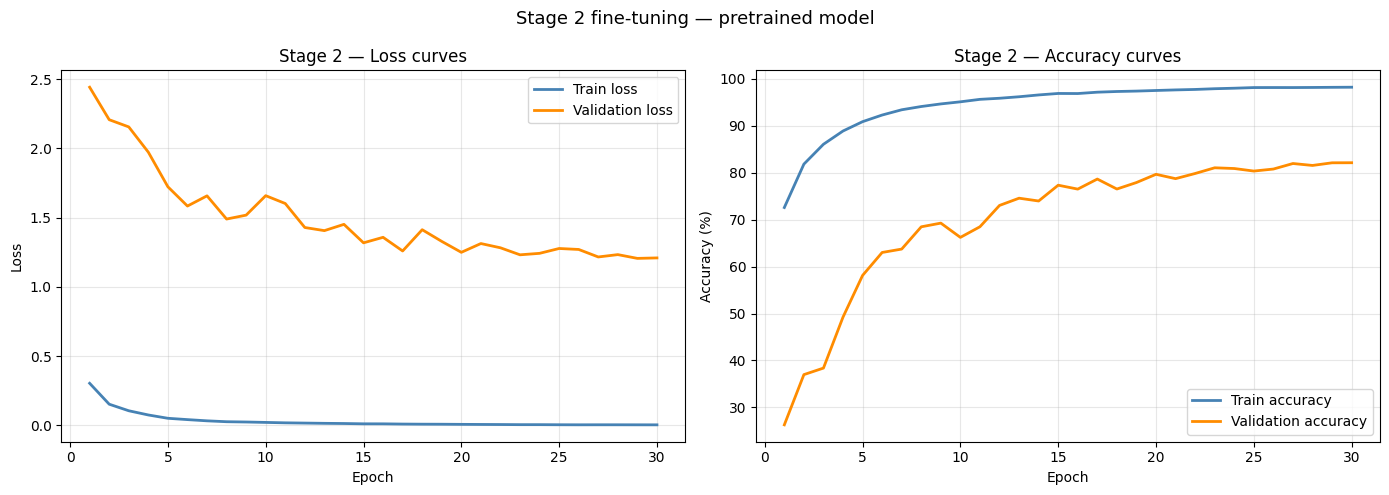

Best validation accuracy: 82.1%
Best validation loss: 1.2062


In [1]:
import numpy as np
import matplotlib.pyplot as plt

history = np.load("../checkpoints/finetune_history.npy", allow_pickle=True).item()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history["train_loss"]) + 1)

ax1.plot(epochs, history["train_loss"], color="steelblue", 
         linewidth=2, label="Train loss")
ax1.plot(epochs, history["val_loss"], color="darkorange", 
         linewidth=2, label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Stage 2 — Loss curves")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history["train_acc"], color="steelblue", 
         linewidth=2, label="Train accuracy")
ax2.plot(epochs, history["val_acc"], color="darkorange", 
         linewidth=2, label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Stage 2 — Accuracy curves")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Stage 2 fine-tuning — pretrained model", fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/finetune_curves_pretrained.png", 
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Best validation accuracy: {max(history['val_acc']):.1f}%")
print(f"Best validation loss: {min(history['val_loss']):.4f}")